In [1]:
!nvidia-smi

Tue Mar 18 07:21:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Here, i assume that one grid can cover the whole matrix C

In [4]:
# Installing nsight-systems-2022.4.1 & nsight-compute-2022.1.1
!apt-get update -y && \
     DEBIAN_FRONTEND=noninteractive apt-get install -y --no-install-recommends \
         apt-transport-https \
         ca-certificates \
         gnupg \
         wget && \
     rm -rf /var/lib/apt/lists/*
!wget -qO - https://developer.download.nvidia.com/devtools/repos/ubuntu2004/amd64/nvidia.pub | apt-key add - && \
     echo "deb https://developer.download.nvidia.com/devtools/repos/ubuntu2004/amd64/ /" >> /etc/apt/sources.list.d/nsight.list && \
     apt-get update -y && \
     DEBIAN_FRONTEND=noninteractive apt-get install -y --no-install-recommends \
         nsight-systems-2022.1.1 nsight-compute-2022.1.1 && \
     rm -rf /var/lib/apt/lists/*

# setting environment variable path
import os
os.environ["PATH"] = "/usr/local/bin" + os.pathsep + os.getenv("PATH")

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,378 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [69.9 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,674 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,535 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 https://ppa.launch

In [5]:
!nsys --version
!echo "---"
!ncu --version

NVIDIA Nsight Systems version 2022.1.1.61-1d07dc0
---
NVIDIA (R) Nsight Compute Command Line Profiler
Copyright (c) 2018-2024 NVIDIA Corporation
Version 2024.2.1.0 (build 34372528) (public-release)


In [6]:
%%writefile kernel1.cu
#include <fstream>
#include <iostream>
#include <cassert>
#include <cuda_runtime.h>

using namespace std;

typedef struct {
  long long unsigned sm_id;
  unsigned long long start_cycle;
  unsigned long long stop_cycle;
  unsigned block_id;
  unsigned warp_id;
} clock64ThreadRecord;




float randomFloat(float min, float max) {
    return min + ((float)rand() / RAND_MAX) * (max - min);
}

int CEIL_DIV(int a, int b)
{
  return (a + b -1 )/ b;
}

__forceinline__ __device__ unsigned get_warp_id() {
  unsigned warp_id;
  asm volatile ("mov.u32 %0, %warpid;" : "=r"(warp_id)); // Lấy warp ID
  return warp_id;
}

__forceinline__ __device__ uint get_smid(void) {
  uint ret;
  asm("mov.u32 %0, %%smid;" : "=r"(ret) );
  return ret;
}

// check the matrix C on GPU and CPU
void checkResult(float *A, float *B, float *C, int M, int N, int K)
{

  float tmp  = 0;

  for (int i = 0; i < (M * N); i++)
  {
    int row = i / N;
    int col = i % N;
    tmp = 0;
    for (int j = 0; j < K; j++)
    {
      tmp += A[row * K + j] * B[col+ N * j];
    }
    if (C[i] != tmp)
    {
      printf("|| C[%d] = %f || tmp = %f \n", i, C[i], tmp);
    }
    //else
    {
      //printf("|| C[%d] = %f || tmp = %f", i, C[i], tmp);
    }

  }
}

__global__ void kernel1(float *d_A, float *d_B, float *d_C, int M, int N, int K, clock64ThreadRecord *records)
{
  unsigned long long start_time = clock64();
  uint row = blockIdx.y * blockDim.y + threadIdx.y;
  uint col = blockIdx.x * blockDim.x + threadIdx.x;
  if(row < M && col < N)
  {
    float tmp = 0;
    for(int i = 0; i < K; i++)
    {
      tmp += d_A[row * K + i] * d_B[col + N * i];
    }
    d_C[row * N + col] = tmp;

    unsigned long long stop_time = clock64();
    unsigned sm_id = get_smid();  // Lấy SM ID
    unsigned warp_id = get_warp_id();       // Lấy Warp ID
    unsigned blockIndex = blockIdx.y * gridDim.x + blockIdx.x;
    // Lưu thông tin profiling vào records
    records[row * N + col] = {sm_id, start_time, stop_time, blockIndex, warp_id};
  }


}

int main()
{
  // initiate size of matrix A, B, C
  int M = 64;
  int N = 64;
  int K = 64;
  int records_size = M * N;
  printf("M = %d, N = %d, K = %d\n", M, N, K);
  // initiate array A, B, C on CPU
  float *h_A = (float *)malloc(M * K * sizeof(float));
  float *h_B = (float *)malloc(K * N * sizeof(float));
  float *h_C = (float *)malloc(M * N * sizeof(float));
  clock64ThreadRecord *h_records = (clock64ThreadRecord *)malloc(M * N * sizeof(clock64ThreadRecord));


  // initiate entry matrix A
  for (int i = 0; i < (M * K); i ++)
  {
    h_A[i] = randomFloat(1, 50);
  }

  // initiate entry matrix B
  for (int i = 0; i < (K * N); i ++)
  {
    h_B[i] = randomFloat(1, 10);
  }

  // allocate memory on GPU
  float *d_A, *d_B, *d_C;
  cudaMalloc(&d_A, M * K * sizeof(float));
  cudaMalloc(&d_B, K * N * sizeof(float));
  cudaMalloc(&d_C, M * N * sizeof(float));
  clock64ThreadRecord *d_records;
  cudaMalloc(&d_records, M * N * sizeof(clock64ThreadRecord));

  //copy matrix A, B from CPU to GPU
  cudaMemcpy(d_A, h_A, M * K * sizeof(float), cudaMemcpyHostToDevice);
  cudaMemcpy(d_B, h_B, K * N * sizeof(float), cudaMemcpyHostToDevice);


  //ddetermine size of grid and block
  dim3 dimGrid(CEIL_DIV(N, 16), CEIL_DIV(M, 16));
  dim3 dimBlock(16, 16);

  // call kernel
  kernel1<<<dimGrid, dimBlock>>>(d_A, d_B, d_C, M, N, K, d_records);

  //copy data Matrix C from GPU to CPU
  cudaMemcpy(h_C, d_C, M * N * sizeof(float), cudaMemcpyDeviceToHost);
  cudaMemcpy(h_records, d_records, M * N * sizeof(clock64ThreadRecord), cudaMemcpyDeviceToHost);

    // Ghi kết quả profiling vào tệp CSV
  std::string csv_path = "output.csv"; // Đường dẫn đến tệp CSV
  std::ofstream file(csv_path);
  file << "SM Id,Block Idx, Warp Id,Start cycle,Stop cycle\n";
  for (int i = 0; i < records_size; i++) {
    file << h_records[i].sm_id << ","
         << h_records[i].block_id << ","
         << h_records[i].warp_id << ","
         << h_records[i].start_cycle << ","
         << h_records[i].stop_cycle << "\n";
  }
  file.close();

  //checkResult(h_A, h_B, h_C, M, N, K);
  //free memory on GPU
  cudaFree(d_A);
  cudaFree(d_B);
  cudaFree(d_C);
  cudaFree(d_records);
  //printf("Done\n");
  free(h_A);
  free(h_B);
  free(h_C);
  free(h_records);

  printf("done\n");
  return 0;

}


Overwriting kernel1.cu


In [7]:
%%bash

nvcc -o kernel1 kernel1.cu -arch=sm_75
./kernel1

# !nvprof --metrics achieved_occupancy ./kernel1

M = 64, N = 64, K = 64
done


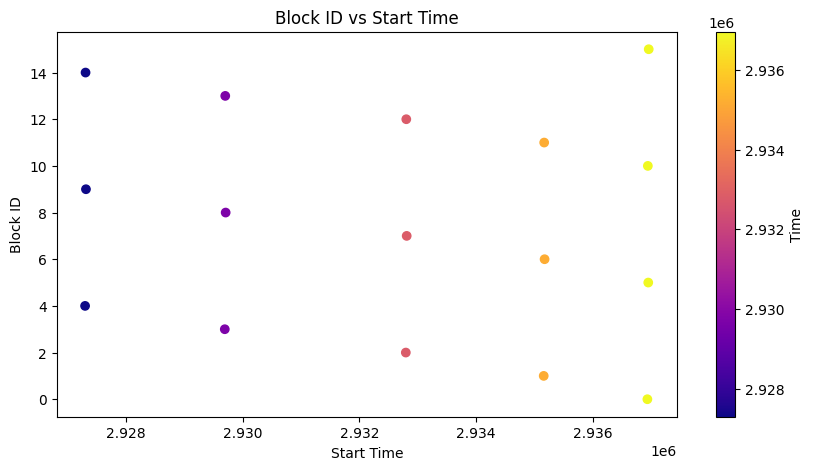

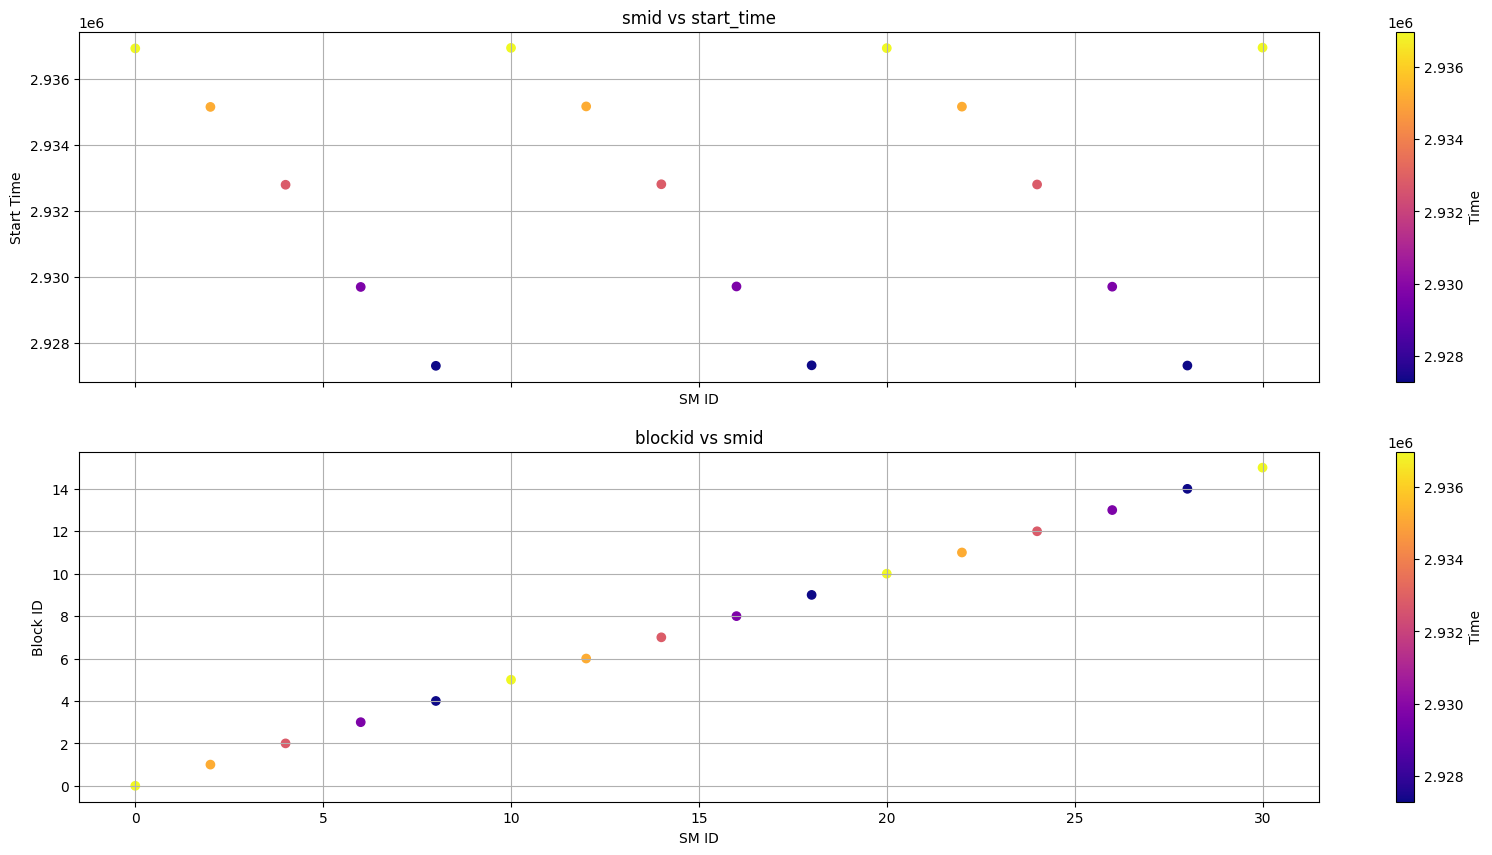

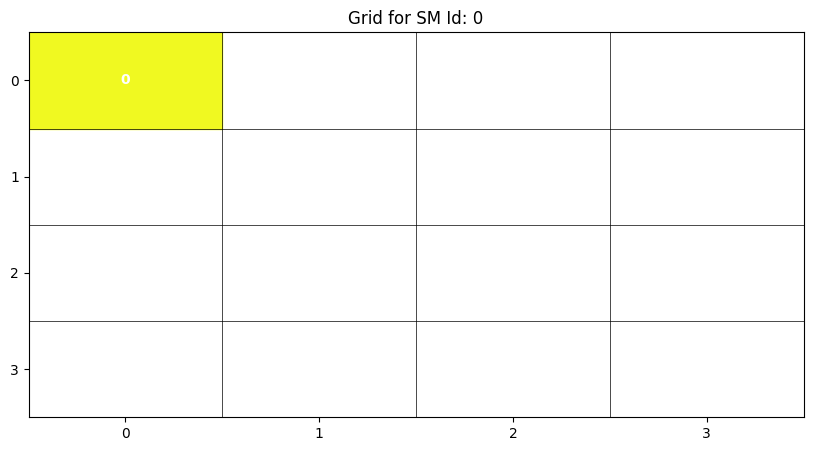

In [11]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def read_csv(file_path):
    with open(file_path, mode='r', newline='') as file:
        csv_reader = csv.reader(file)
        # for row in csv_reader:
        #     print(row)


def CEIL_DIV(a, b):
  return int((a + b -1 )/ b);

M = 64
N = 64
K = 64
SM_number = 0
smid = []
blockid  = []
warpid = []
start_time = []
stop_time = []
if __name__ == "__main__":
    file_path = 'output.csv'  # Update this path if your CSV file is located elsewhere
    read_csv(file_path)
    #đọc cột thứ nhất và thứ 4 trong file csv
    with open(file_path, mode='r', newline='') as file:
        csv_reader = csv.reader(file)
        next(csv_reader)  # Skip the header row
        for row in csv_reader:
            # print(row[0], row[3])
            # lưu vào mảng smid và start_time
            smid.append(row[0])
            blockid.append(row[1])
            warpid.append(row[2])
            start_time.append(row[3])
            stop_time.append(row[4])
# vẽ smid và start_time biết
# smid là trục y
# start_time là trục x
smid.pop(0)
blockid.pop(0)
warpid.pop(0)
start_time.pop(0)
stop_time.pop(0)


smid = list(map(int, smid))
blockid = list(map(int, blockid))
warpid = list(map(int, warpid))
start_time = list(map(int, start_time))
stop_time = list(map(int, stop_time))



# map 3 mảng lại với nhau
combined = list(zip(smid, blockid, warpid, start_time, stop_time))
combined.sort(key = lambda x : x[1])
# print(blockid)

smid_new = []
blockid_new = []
warpid_new = []
start_time_new = []

prev_blockid = None  # Biến lưu blockid trước đó để kiểm tra trùng lặp

for sm, blk, warp, start, stop in combined:
    if blk != prev_blockid:  # Nếu blockid khác trước đó, thêm vào danh sách mới
        smid_new.append(sm)
        blockid_new.append(blk)
        warpid_new.append(warp)
        start_time_new.append(start)
    prev_blockid = blk  # Cập nhật blockid trước đó


combined = list(zip(smid_new, blockid_new, warpid_new, start_time_new))
combined.sort(key = lambda x : x[3])

# Chọn colormap và chuẩn hóa giá trị block ID
cmap = plt.cm.plasma  # Bạn có thể đổi sang 'viridis', 'inferno', 'coolwarm', ...
norm = mcolors.Normalize(vmin=min(start_time_new), vmax=max(start_time_new))

# ve bieu do block va start time id
plt.figure(figsize=(10, 5))
plt.scatter(start_time_new, blockid_new, c = start_time_new, cmap=cmap, norm=norm)
plt.xlabel('Start Time')
plt.ylabel('Block ID')
plt.title('Block ID vs Start Time')
plt.colorbar(label='Time')
# ve bieu do smid va block thay doi theo start time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

# for (smid, start_time, time) in zip(smid_new, start_time_new, start_time_new):
    # color = cmap(norm(time))  # Lấy màu theo Block ID
    # ax1.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color=color))
    # ax1.text(x, y, str(blk), color="white", ha='center', va='center', fontsize=10, fontweight='bold')
# Vẽ biểu đồ đầu tiên
# scatter1 = ax1.scatter(smid_new, start_time_new, c=colors, cmap='viridis')
scatter1 = ax1.scatter(smid_new, start_time_new, c = start_time_new, cmap=cmap, norm=norm)

ax1.set_xlabel('SM ID')
ax1.set_ylabel('Start Time')
ax1.set_title('smid vs start_time')
ax1.grid(True)
fig.colorbar(scatter1, ax=ax1, label='Time')

# Vẽ biểu đồ thứ hai
scatter2 = ax2.scatter(smid_new, blockid_new, c=start_time_new, cmap=cmap, norm=norm)
ax2.set_xlabel('SM ID')
ax2.set_ylabel('Block ID')
ax2.set_title('blockid vs smid')
ax2.grid(True)
fig.colorbar(scatter2, ax=ax2, label='Time')

x_smid0 = []
y_smid0 = []
time_smid0 = []
for i in range(len(smid_new)):
    if smid_new[i] == SM_number:
        x_smid0.append(blockid_new[i] % CEIL_DIV(N, 16))
        # print(blockid_new[i] )
        y_smid0.append(blockid_new[i] // CEIL_DIV(N, 16))
        time_smid0.append(start_time_new[i])
    # else:
    #     smid_new[i] = 1

# Kích thước của lưới
rows, cols = CEIL_DIV(N, 16), CEIL_DIV(M, 16)

# Tạo figure và axes
fig, ax = plt.subplots(figsize=(10, 5))

# Vẽ lưới
ax.set_xticks(np.arange(cols + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(rows + 1) - 0.5, minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", size=0)



# # Tô màu các ô đã chọn
# for (x, y) in zip(x_smid0, y_smid0):
#     ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color="navy")) #
#     ax.text(x , y , 'x', color="red", ha='center', va='center', fontsize=8)

# Tô màu các ô đã chọn với colormap theo Block ID
for (x, y, time) in zip(x_smid0, y_smid0, time_smid0):
    color = cmap(norm(time))  # Lấy màu theo Block ID
    ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color=color))
    blk = y * CEIL_DIV(N, 16) + x
    ax.text(x, y, str(blk), color="white", ha='center', va='center', fontsize=10, fontweight='bold')
# Định dạng trục
ax.set_xlim(-0.5, cols - 0.5)
ax.set_ylim(rows - 0.5, -0.5)
ax.set_xticks(np.arange(cols))
ax.set_yticks(np.arange(rows))
ax.set_title(f"Grid for SM Id: {SM_number}")

plt.show()

In [ ]:
!nvcc my_kernel.cu -o my_kernel